In [3]:
pip install util-gfsilveira

In [2]:
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#Carregar o modelo
from keras.models import load_model
#salvar/carregar arquivos em diferentes formatos
import joblib

In [4]:
#Importando o modelo contendo os valores previstos para o número de células nas imagens
modelo_maior_erro = load_model('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/teste modelos/modelo_fluore_HUVEC_100_75_50_25_2025-11-13.keras')
modelo_maior_erro

<Sequential name=sequential, built=True>

In [5]:
X_test_maior_erro = joblib.load('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HUVEC/imagens_HUVEC_validação_10%_fluore_2025-11-13.gz') #carregando arquivo
X_test_maior_erro.shape

(29, 300, 300, 3)

In [6]:
y_test_maior_erro = joblib.load('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HUVEC/rótulos_HUVEC_validação_10%_fluore_2025-11-13.gz') #carregando arquivo
y_test_maior_erro.shape

(29,)

In [7]:
#ROTULOS SALVOS EM LISTA

lista_observado_maior_erro = list(y_test_maior_erro)
len(lista_observado_maior_erro)

29

In [8]:
#PREDIÇÃO SALVO EM LISTA

dados_prev = modelo_maior_erro.predict(X_test_maior_erro)
lista_previsto_maior_erro = dados_prev.flatten().tolist()
len(lista_previsto_maior_erro)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


29

In [9]:
lista_previsto_maior_erro

[0.06750291585922241,
 0.06805410236120224,
 0.07621503621339798,
 0.07310258597135544,
 0.07459322363138199,
 0.06616286188364029,
 0.06817388534545898,
 0.07290124148130417,
 0.07438567280769348,
 0.07603640109300613,
 0.052927326411008835,
 0.06382140517234802,
 0.21252621710300446,
 0.06756942719221115,
 0.06409649550914764,
 0.17200440168380737,
 0.21050436794757843,
 0.0725829005241394,
 0.0736175999045372,
 0.06565649062395096,
 0.07019131630659103,
 0.0684058666229248,
 0.06793978810310364,
 0.06909287720918655,
 0.10901906341314316,
 0.06841760128736496,
 0.2069299966096878,
 0.0696144625544548,
 0.06770578026771545]

In [10]:
import pandas as pd
from scipy.stats.stats import pearsonr as stats

/tmp/ipython-input-3864774765.py:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr as stats


In [11]:
#DATAFRAME - ORGANIZAÇÃO DAS LISTAS
#COLUNA 1 ROTULO/ COLUNA 2 PREDITO

df_maior_erro = pd.DataFrame(zip(lista_observado_maior_erro,lista_previsto_maior_erro),
                             columns = ['Observed values','Lista preditos'])
df_maior_erro.head()

,Observed values,Lista preditos
0,0.067018,0.067503
1,0.067453,0.068054
2,0.071255,0.076215
3,0.071514,0.073103
4,0.068888,0.074593


In [12]:
#ARREDONDANDO O PREDITO ('lista preditos')

teste = round(df_maior_erro['Lista preditos'],2)
df_maior_erro['Predicted values'] = teste
df_maior_erro.head()

,Observed values,Lista preditos,Predicted values
0,0.067018,0.067503,0.07
1,0.067453,0.068054,0.07
2,0.071255,0.076215,0.08
3,0.071514,0.073103,0.07
4,0.068888,0.074593,0.07


In [13]:
#REORGANIZANDO AS COLUNAS

df_maior_erro = df_maior_erro.reindex(columns=['Observed values','Predicted values','Lista preditos'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos
0,0.067018,0.07,0.067503
1,0.067453,0.07,0.068054
2,0.071255,0.08,0.076215
3,0.071514,0.07,0.073103
4,0.068888,0.07,0.074593


In [14]:
#BIBLIOTECA CORRELAÇÃO
from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação

/tmp/ipython-input-923420305.py:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação


In [15]:
# #CALCULO DE CORRELAÇÃO

col1_obt = 0 #Observed value
col2_prev = 1 #Predicted values
pear_pos_maior_erro = stats(df_maior_erro[df_maior_erro.columns[col1_obt]],
                            df_maior_erro[df_maior_erro.columns[col2_prev]])

AttributeError: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'

In [16]:
from scipy import stats

# Verifique se as colunas contêm apenas valores numéricos
df_maior_erro[df_maior_erro.columns[col1_obt]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col1_obt]], errors='coerce')
df_maior_erro[df_maior_erro.columns[col2_prev]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col2_prev]], errors='coerce')

# Remova as linhas com valores NaN resultantes da conversão
df_maior_erro = df_maior_erro.dropna(subset=[df_maior_erro.columns[col1_obt], df_maior_erro.columns[col2_prev]])

# Calcular a correlação
pear_pos_maior_erro = stats.pearsonr(df_maior_erro[df_maior_erro.columns[col1_obt]],
                                     df_maior_erro[df_maior_erro.columns[col2_prev]])

print(pear_pos_maior_erro)

PearsonRResult(statistic=np.float64(0.5562939907867404), pvalue=np.float64(0.0017262289864871932))


<Figure size 1500x1500 with 0 Axes>

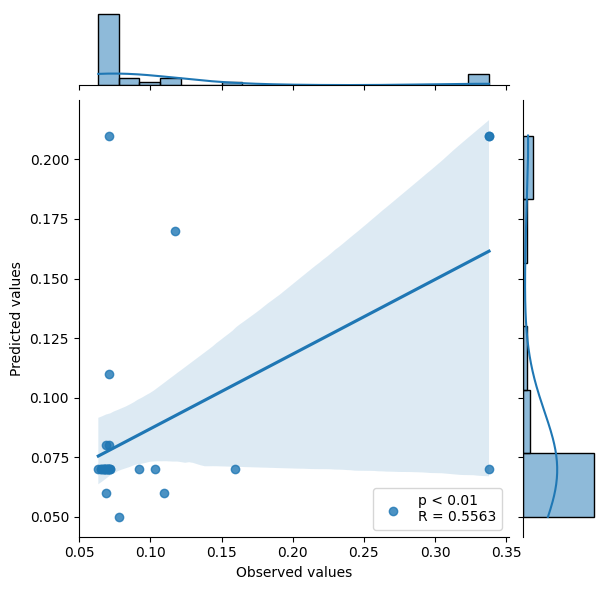

In [17]:
plt.figure(figsize=(15,15))
sns.jointplot(
    x=df_maior_erro.columns[col1_obt],
    y=df_maior_erro.columns[col2_prev],
    kind='reg',
    data=df_maior_erro#[df_maior_erro['Lista observado'] > 300]
)

if pear_pos_maior_erro[1] < 0.01:
  plt.legend(['p < ' + '0.01' + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e relse:
else:
  plt.legend(['p = ' + str(round(pear_pos_maior_erro[1],4)) + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e r

#Predição do modelo

In [18]:
predictions = modelo_maior_erro.predict(X_test_maior_erro)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [19]:
# Compara as previsões com os valores reais
for i in range(len(predictions)):
    print(f"Valor real: {y_test_maior_erro[i]}, Valor predito: {predictions[i]}")

Valor real: 0.067018, Valor predito: [0.06750292]
Valor real: 0.067453, Valor predito: [0.0680541]
Valor real: 0.071255, Valor predito: [0.07621504]
Valor real: 0.071514, Valor predito: [0.07310259]
Valor real: 0.068888, Valor predito: [0.07459322]
Valor real: 0.065635, Valor predito: [0.06616286]
Valor real: 0.067398, Valor predito: [0.06817389]
Valor real: 0.070178, Valor predito: [0.07290124]
Valor real: 0.065635, Valor predito: [0.07438567]
Valor real: 0.068760, Valor predito: [0.0760364]
Valor real: 0.078077, Valor predito: [0.05292733]
Valor real: 0.109804, Valor predito: [0.06382141]
Valor real: 0.338015, Valor predito: [0.21252622]
Valor real: 0.071255, Valor predito: [0.06756943]
Valor real: 0.068760, Valor predito: [0.0640965]
Valor real: 0.117536, Valor predito: [0.1720044]
Valor real: 0.338015, Valor predito: [0.21050437]
Valor real: 0.070044, Valor predito: [0.0725829]
Valor real: 0.070038, Valor predito: [0.0736176]
Valor real: 0.068760, Valor predito: [0.06565649]
Valor 

#Predição de Frequência Absoluta

In [21]:
df_maior_erro


,Observed values,Predicted values,Lista preditos
0,0.067018,0.07,0.067503
1,0.067453,0.07,0.068054
2,0.071255,0.08,0.076215
3,0.071514,0.07,0.073103
4,0.068888,0.07,0.074593
5,0.065635,0.07,0.066163
6,0.067398,0.07,0.068174
7,0.070178,0.07,0.072901
8,0.065635,0.07,0.074386
9,0.068760,0.08,0.076036


In [22]:
df_maior_erro['Diferença'] = df_maior_erro['Observed values'] - df_maior_erro['Predicted values']

In [23]:
df_maior_erro

,Observed values,Predicted values,Lista preditos,Diferença
0,0.067018,0.07,0.067503,-0.002982
1,0.067453,0.07,0.068054,-0.002547
2,0.071255,0.08,0.076215,-0.008745
3,0.071514,0.07,0.073103,0.001514
4,0.068888,0.07,0.074593,-0.001112
5,0.065635,0.07,0.066163,-0.004365
6,0.067398,0.07,0.068174,-0.002602
7,0.070178,0.07,0.072901,0.000178
8,0.065635,0.07,0.074386,-0.004365
9,0.068760,0.08,0.076036,-0.011240


In [24]:
import matplotlib.pyplot as plt

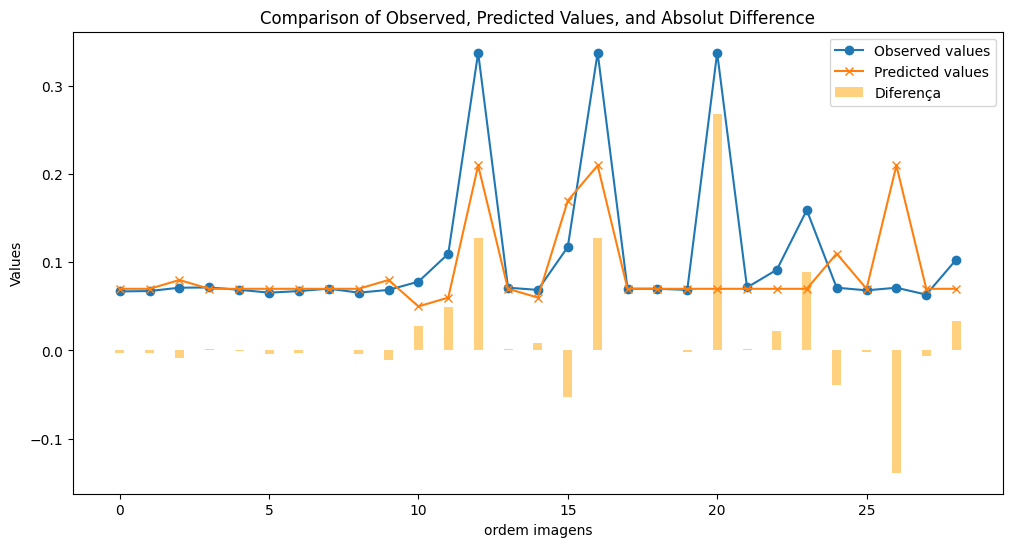

In [25]:
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença
plt.bar(df_maior_erro.index, df_maior_erro['Diferença'], width=0.3, alpha=0.5, label='Diferença', color='orange')

# Adiciona rótulos e título
plt.xlabel('ordem imagens')
plt.ylabel('Values')
plt.title('Comparison of Observed, Predicted Values, and Absolut Difference')
plt.legend()

# Mostra o gráfico
plt.show()

#Previsão Frequência Relativa (%)

In [26]:
#Calcula a diferença relativa entre o valor real e o valor predito (em %)
# df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Observed values'] - df_maior_erro['Predicted values']) / df_maior_erro['Observed values']) * 100
# df_maior_erro.head()

In [27]:
df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Predicted values']*100) / df_maior_erro['Observed values'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos,Diferença,Relative Difference (%)
0,0.067018,0.07,0.067503,-0.002982,104.449551
1,0.067453,0.07,0.068054,-0.002547,103.775963
2,0.071255,0.08,0.076215,-0.008745,112.272823
3,0.071514,0.07,0.073103,0.001514,97.882932
4,0.068888,0.07,0.074593,-0.001112,101.614214


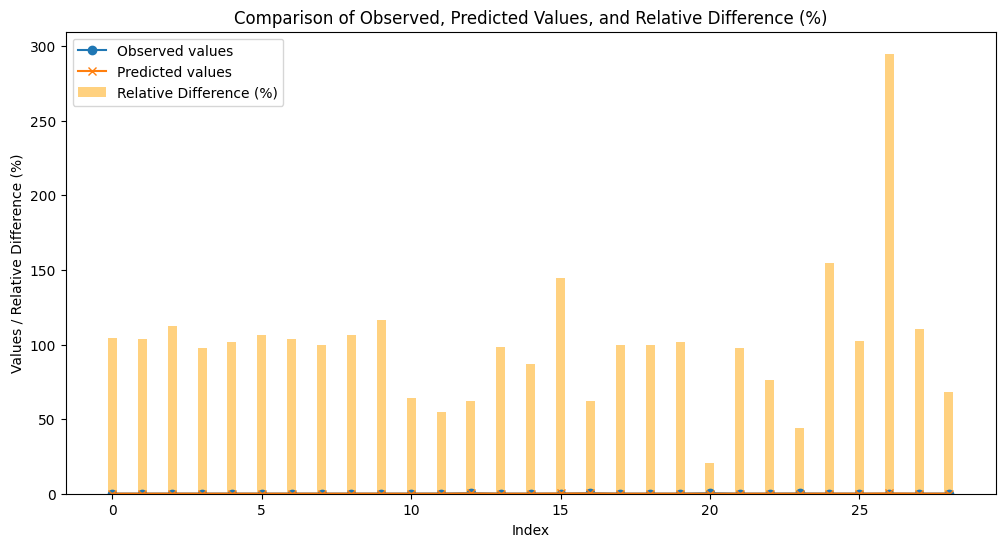

In [28]:
# Cria o gráfico comparando os valores
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença relativa
plt.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=0.3, alpha=0.5, label='Relative Difference (%)', color='orange')

# Adiciona rótulos e título
plt.xlabel('Index')
plt.ylabel('Values / Relative Difference (%)')
plt.title('Comparison of Observed, Predicted Values, and Relative Difference (%)')
plt.legend()

# Mostra o gráfico
plt.show()

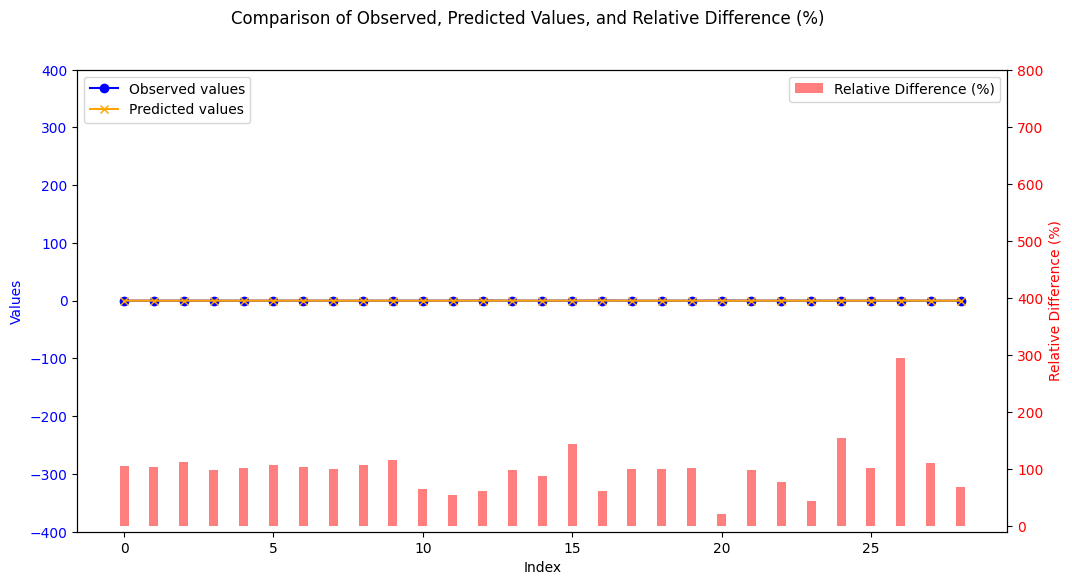

In [29]:
# Cria o gráfico com dois eixos Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Y da esquerda (para valores observados e preditos)
ax1.set_xlabel('Index')
ax1.set_ylabel('Values', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x', color='orange')
ax1.tick_params(axis='y', labelcolor='blue')

# Mantém a escala normal do eixo Y da esquerda
# ax1.set_ylim(df_maior_erro[['Observed values', 'Predicted values']].min().min(),
#              df_maior_erro[['Observed values', 'Predicted values']].max().max())
ax1.set_ylim(-400, 400)

# Adiciona o segundo eixo Y à direita (para diferença relativa)
ax2 = ax1.twinx()
ax2.set_ylabel('Relative Difference (%)', color='red')


# Ajusta a largura das barras
bar_width = 0.3
ax2.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=bar_width, alpha=0.5, label='Relative Difference (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Corrige a amplitude do eixo Y da direita para -15 a 300
ax2.set_ylim(-10, 800)

# Títulos e legendas
fig.suptitle('Comparison of Observed, Predicted Values, and Relative Difference (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Mostra o gráfico
plt.show()